In [20]:
print("AKHIL C")
print("24BAD007")

AKHIL C
24BAD007


# Scenario 1 – Movie Recommendation using SVD


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

## 2. Load Dataset

In [2]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
print(ratings.shape)
ratings.head()

(100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 3. Data Preprocessing

In [3]:
print(ratings.isnull().sum())
print(f"Users: {ratings['userId'].nunique()}, Movies: {ratings['movieId'].nunique()}")
print(ratings['rating'].describe())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Users: 610, Movies: 9724
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42, stratify=pd.cut(ratings['rating'], bins=[0,2,3,4,5], labels=False))
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Train: 80668, Test: 20168


## 4. Create User-Item Interaction Matrix

In [5]:
user_item_matrix = train_data.pivot_table(index='userId', columns='movieId', values='rating')
print(f"Matrix shape: {user_item_matrix.shape}")
sparsity = user_item_matrix.isnull().sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"Sparsity: {sparsity:.2%}")

Matrix shape: (610, 8944)
Sparsity: 98.52%


## 5. Normalize the Matrix (Mean Centering)

In [6]:
# Compute global, user, and item biases for better centering
global_mean = user_item_matrix.stack().mean()
user_means = user_item_matrix.mean(axis=1)
item_means = user_item_matrix.mean(axis=0)

# Center by user mean; remaining NaNs → 0 (no observed rating)
matrix_filled = user_item_matrix.subtract(user_means, axis=0).fillna(0).values
print(f"Global mean: {global_mean:.4f}")
print(f"Matrix ready for SVD: {matrix_filled.shape}")

Global mean: 3.5015
Matrix ready for SVD: (610, 8944)


## 6. Apply SVD Decomposition

In [7]:
U, sigma, Vt = np.linalg.svd(matrix_filled, full_matrices=False)
print(f"U: {U.shape}, sigma: {sigma.shape}, Vt: {Vt.shape}")

U: (610, 610), sigma: (610,), Vt: (610, 8944)


## 7. Reduce Dimensions (Select k Latent Factors)

In [8]:
# Choose k that explains ≥ 90% of variance
explained = np.cumsum(sigma**2) / np.sum(sigma**2)
k = int(np.searchsorted(explained, 0.90)) + 1
k = min(k, 150)   # cap for speed
print(f"k chosen = {k}  (explains {explained[k-1]*100:.1f}% of variance)")

U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]
print(f"Reduced: U_k={U_k.shape}, sigma_k={sigma_k.shape}, Vt_k={Vt_k.shape}")

k chosen = 150  (explains 78.0% of variance)
Reduced: U_k=(610, 150), sigma_k=(150, 150), Vt_k=(150, 8944)


## 8. Reconstruct the Matrix

In [9]:
reconstructed = np.dot(U_k, np.dot(sigma_k, Vt_k))

# Add back user mean + item bias correction (item_mean - global_mean)
item_bias = (item_means - global_mean).values.reshape(1, -1)
reconstructed_df = pd.DataFrame(
    reconstructed + user_means.values.reshape(-1, 1) + item_bias,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)
reconstructed_df = reconstructed_df.clip(0.5, 5.0)

## 9. Predict Missing Ratings

In [10]:
# Vectorized prediction — much faster than iterrows
test_subset = test_data[
    test_data['userId'].isin(reconstructed_df.index) &
    test_data['movieId'].isin(reconstructed_df.columns)
].copy()

# Use integer-position lookup via index maps for speed
user_idx = {u: i for i, u in enumerate(reconstructed_df.index)}
movie_idx = {m: j for j, m in enumerate(reconstructed_df.columns)}
rec_arr = reconstructed_df.values

row_ids = test_subset['userId'].map(user_idx).values
col_ids = test_subset['movieId'].map(movie_idx).values
preds   = rec_arr[row_ids, col_ids]
actuals = test_subset['rating'].values

def predict_rating(user_id, movie_id):
    if user_id in reconstructed_df.index and movie_id in reconstructed_df.columns:
        return reconstructed_df.loc[user_id, movie_id]
    return None

In [11]:
rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 0.9057
MAE:  0.6888


## 10. Generate Top-N Recommendations

In [12]:
def get_top_n(user_id, n=10):
    rated = train_data[train_data['userId'] == user_id]['movieId'].values
    user_preds = reconstructed_df.loc[user_id].drop(index=rated, errors='ignore')
    top_movies = user_preds.nlargest(n).index
    return movies[movies['movieId'].isin(top_movies)][['movieId', 'title']].set_index('movieId').loc[top_movies]

print("Top 10 recommendations for User 1:")
get_top_n(1, 10)

Top 10 recommendations for User 1:


,title
movieId,
28,Persuasion (1995)
29,"City of Lost Children, The (Cité des enfants p..."
32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
40,"Cry, the Beloved Country (1995)"
47,Seven (a.k.a. Se7en) (1995)
50,"Usual Suspects, The (1995)"
53,Lamerica (1994)
61,Eye for an Eye (1996)
85,Angels and Insects (1995)


In [13]:
k_values = [5, 10, 20, 50, 100, 150, 200]
rmse_list = []

for k_val in k_values:
    k_val = min(k_val, len(sigma))
    rec = np.dot(U[:, :k_val], np.dot(np.diag(sigma[:k_val]), Vt[:k_val, :]))
    rec_df = pd.DataFrame(
        rec + user_means.values.reshape(-1, 1),
        index=user_item_matrix.index,
        columns=user_item_matrix.columns
    ).clip(0.5, 5.0)
    p = [rec_df.loc[r['userId'], r['movieId']] if r['userId'] in rec_df.index and r['movieId'] in rec_df.columns else None
         for _, r in test_subset.iterrows()]
    p = np.array(p, dtype=float)
    rmse_list.append(np.sqrt(mean_squared_error(actuals, p)))

print("k values and RMSE:")
for k_val, r in zip(k_values, rmse_list):
    print(f"  k={k_val:3d} -> RMSE={r:.4f}")

k values and RMSE:
  k=  5 -> RMSE=0.9080
  k= 10 -> RMSE=0.9061
  k= 20 -> RMSE=0.9096
  k= 50 -> RMSE=0.9182
  k=100 -> RMSE=0.9262
  k=150 -> RMSE=0.9304
  k=200 -> RMSE=0.9330


## Visualizations

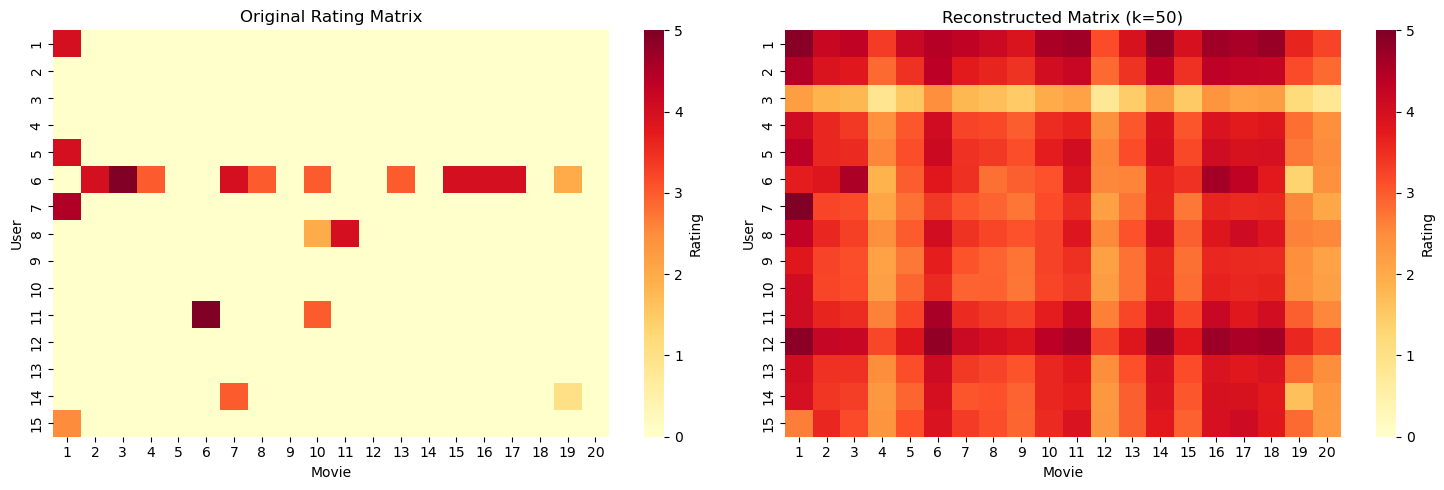

In [19]:
# Heatmap: original vs reconstructed (small subset)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

subset_users = user_item_matrix.index[:15]
subset_movies = user_item_matrix.columns[:20]

orig_sub = user_item_matrix.loc[subset_users, subset_movies].fillna(0)
rec_sub = reconstructed_df.loc[subset_users, subset_movies]

sns.heatmap(orig_sub, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Rating'}, vmin=0, vmax=5)
axes[0].set_title('Original Rating Matrix')
axes[0].set_xlabel('Movie')
axes[0].set_ylabel('User')

sns.heatmap(rec_sub, ax=axes[1], cmap='YlOrRd', cbar_kws={'label': 'Rating'}, vmin=0, vmax=5)
axes[1].set_title('Reconstructed Matrix (k=50)')
axes[1].set_xlabel('Movie')
axes[1].set_ylabel('User')

plt.tight_layout()
plt.show()

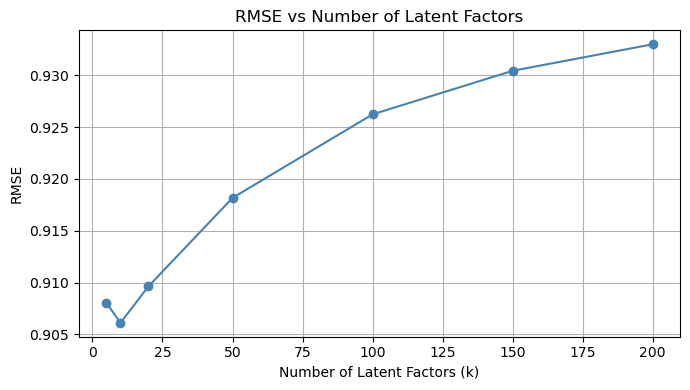

In [15]:
# RMSE vs k
plt.figure(figsize=(7, 4))
plt.plot(k_values, rmse_list, marker='o', color='steelblue')
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('RMSE')
plt.title('RMSE vs Number of Latent Factors')
plt.grid(True)
plt.tight_layout()
plt.show()

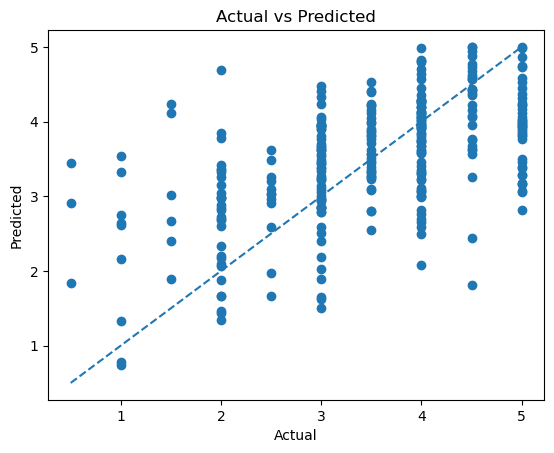

In [16]:
plt.figure()

plt.scatter(actuals[:300], preds[:300])
plt.plot([0.5, 5], [0.5, 5], '--')

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()

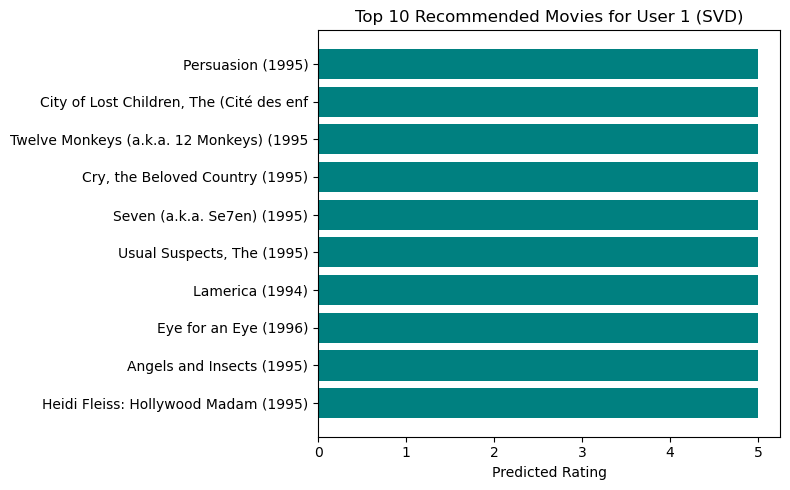

In [17]:
# Top recommended movies for user 1
top_recs = get_top_n(1, 10)
scores = reconstructed_df.loc[1, top_recs.index]

plt.figure(figsize=(8, 5))
plt.barh(top_recs['title'].str[:40].values[::-1], scores.values[::-1], color='teal')
plt.xlabel('Predicted Rating')
plt.title('Top 10 Recommended Movies for User 1 (SVD)')
plt.tight_layout()
plt.show()